In [1]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import pandas as pd
from tqdm import tqdm
plt.rcParams['image.origin'] = 'lower'
from analytical_model import *
import matplotlib as mpl

%load_ext autoreload
%autoreload 2

(-10.0, 1.0)

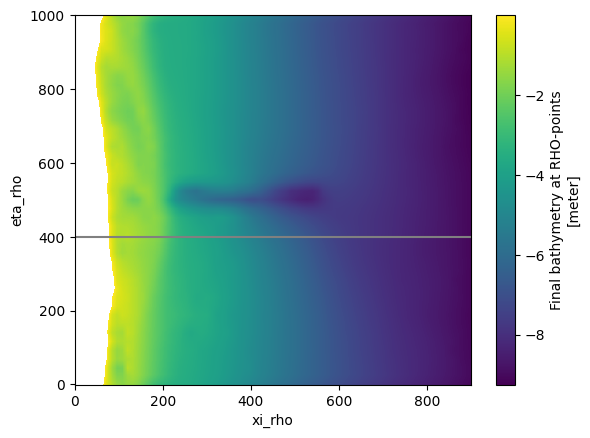

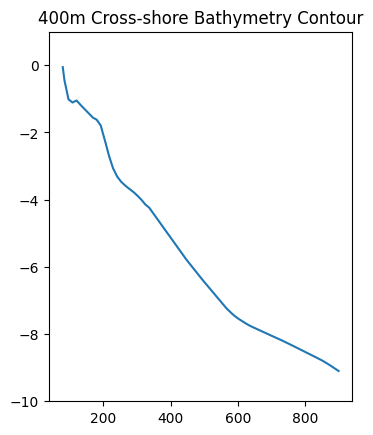

In [2]:
# Take a bathy profile. We'll consider a cross shore transect at 400m alongshore in this reference frame
# TODO(@mleclair): Figure out what this is in FRF coordinates?
crossshore_loc = 400
bathy = xr.load_dataset('../model/code/bathy/FRF_geomorphology_DEMs_surveyDEM_20211021/FRF_geomorphology_DEMs_surveyDEM_20211021_grid.nc')
bathy['h'].values *= -1 # Depth is negative
bathy['h'].values[bathy.h.values >= 0] = np.nan # No positive depths
bathy.h.plot()
plt.axhline(crossshore_loc, c='gray')
ny, nx = bathy.h.shape

# Here's that contour 
plt.figure()
h_contour = (-bathy.h.sel(eta_rho=crossshore_loc)).values
plt.plot(np.arange(901), -h_contour)
plt.title(f'{crossshore_loc}m Cross-shore Bathymetry Contour')
plt.gca().set_aspect(100)
plt.ylim(-10, 1)

In [3]:
# Some metadata from this mission showing forcing from the 8m array
missions = pd.read_csv('../data/mission_df.csv')
mission = missions[missions['mission number']==32]
mission

,Unnamed: 0,time,mission number,Hs [m],Tm [s],Mean Dir [deg],cross shore gamma location [m],break depth,freq [hz],energy density [m^2\hz],direction bins [deg],directional energy density [m^2/hz/deg],wind speed [m/s],wind direction [deg],water level [m]
39,39,2021-10-13 17:25:29.998680,32,1.091753,6.456496,59.175695,263.470935,3.119293,"[0.03999999910593033, 0.04749999940395355, 0.0...","[0.01459356204863603, 0.013802312733134417, 0....","[0.0, 5.0, 10.0, 15.0, 20.0, 25.0, 30.0, 35.0,...","[[4.0894119592849165e-05, 4.2284758819732815e-...",6.483833,4.238652,0.781


In [4]:
# Let's calculate some wave statistics
H_s = mission['Hs [m]'].item()
H_rms = H_s_to_H_rms(H_s)

# Rough estimate of the total number of waves during the measurement period as # of peak periods
minutes_of_data = 120
N = (minutes_of_data * 60) / mission['Tm [s]'].item() 

# Maximum wave height following 
# The statistical distribution of the maxima of a random function  [Cartwright & Longuet-Higgins, 1956] https://doi.org/10.1098/rspa.1956.0173
H_max = calculate_H_max(H_rms, N)
print(f"{H_s=:.2f}m")
print(f"{H_rms=:.2f}m")
print(f"{H_max=:.2f}m")

H_s_offshore = H_s
H_rms_offshore = H_rms
H_max_offshore = H_max

nH = 200
H = np.linspace(0, H_max_offshore, nH)
dH_offshore = H[1] - H[0]
pH_offshore = rayleight_distribution(H, H_rms_offshore)



# To visualize this we'll create a grid of (H, X), (Wave heights, Cross-shore grid points)
H_grid = (np.ones(nx)[:, np.newaxis] * H[np.newaxis, :]).T
assert(H_grid.shape == (nH, nx))

H_s=1.09m
H_rms=0.77m
H_max=2.13m


Text(0, 0.5, 'p(H)')

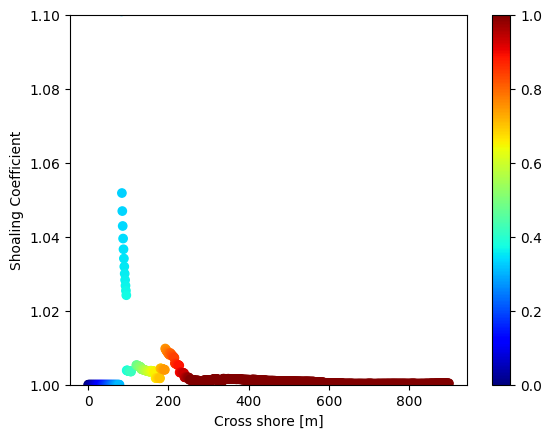

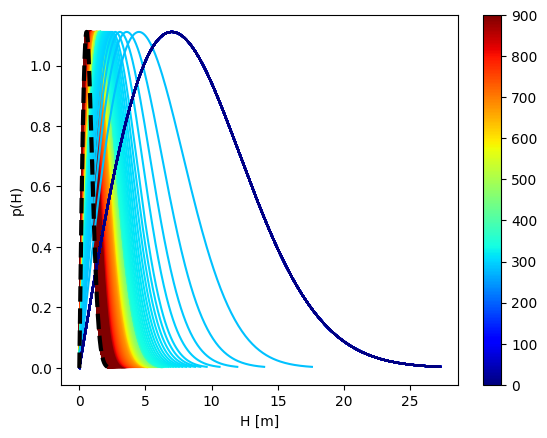

In [5]:
# Calculate the Shoaling Coefficient, rounding to zero when 
shoaling_coefficient = shoaling_coefficient(bathy.h.values[400])
fig, ax = plt.subplots()
ax.scatter(np.arange(nx-1), shoaling_coefficient, c=plt.cm.jet(np.arange(nx-1)))
ax.set_ylim(1, 1.1)
cmap = plt.cm.jet
norm = mpl.colors.Normalize(vmin=0, vmax=1)
plt.colorbar(plt.cm.ScalarMappable(norm=norm, cmap=cmap), ax=ax)
ax.set_xlabel('Cross shore [m]')
ax.set_ylabel('Shoaling Coefficient')

fig, ax = plt.subplots()

ax.plot(H, pH_offshore, c='k', zorder=5, linewidth=3, linestyle='--')
shoaled_h = H.copy()
for i in reversed(range(nx-1)):
    shoaled_h *= shoaling_coefficient[i]
    ax.plot(shoaled_h, pH_offshore, c=plt.cm.jet(i))
cmap = plt.cm.jet
norm = mpl.colors.Normalize(vmin=0, vmax=900)
plt.colorbar(plt.cm.ScalarMappable(norm=norm, cmap=cmap), ax=ax)

ax.set_xlabel('H [m]')
ax.set_ylabel('p(H)')

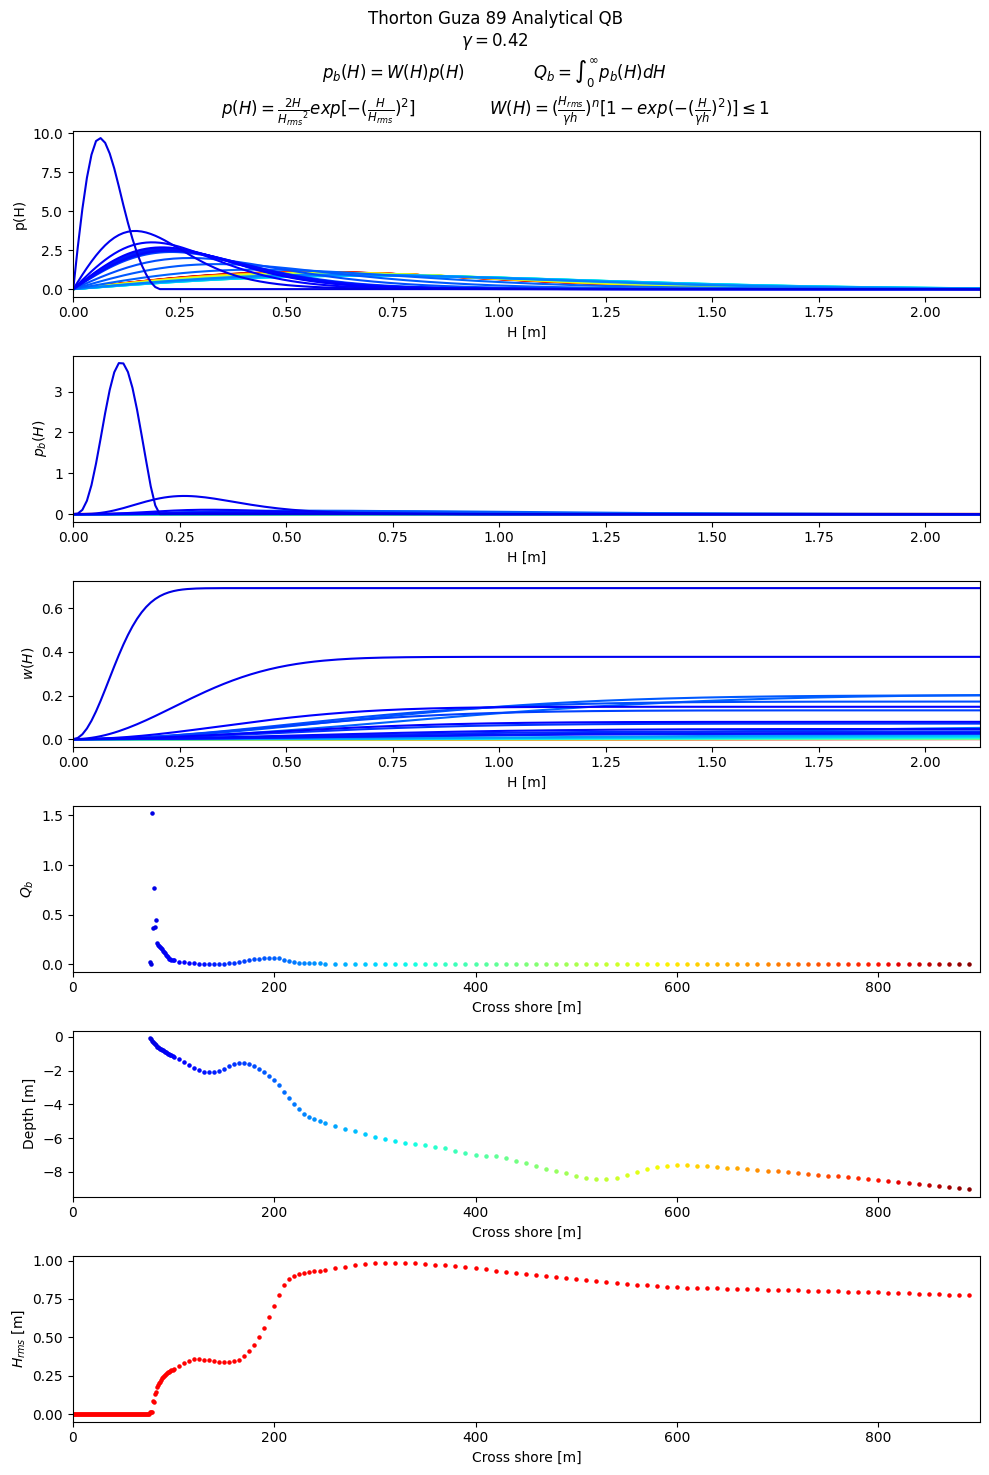

In [6]:
gamma = 0.42
i = 500
update_hrms = True
shoal_H = True 
shoal_H = True
update_H=True

pH = pH_offshore
hrms=np.nan_to_num(np.sqrt(np.trapz(H**2 * pH, H)), 0)
colors = plt.cm.jet(np.arange(900))    
modified_pHs = np.zeros((nx, nH))
modified_Hs = np.zeros((nx, nH))
qb = np.zeros((nx))

fig, axs = plt.subplots(6, 1, figsize=(10,15))
shoaled_H = H.copy()
for j in reversed(range(900)):
    h = bathy.h.values[i, j]
    if shoal_H:
        # This shifts pH onto the shoaled heights of the waves.
        pH = np.interp(shoaled_H, shoaled_H * shoaling_coefficient[j], pH)
        # shoaled_H = shoaled_H * shoaling_coefficient[j]
        # pH = pH * shoaling_coefficient[j]
    
    if update_hrms:
        hrms=np.nan_to_num(np.sqrt(np.trapz(shoaled_H**2 * pH, shoaled_H)), 1e-9)
    
    wH = TG89_W(shoaled_H, H_rms=hrms, h=h, gamma=gamma, n=4)
    pb = pH * wH
    if update_H:
        pH -= pb
        pH = pH/np.maximum(np.nan_to_num(np.sum(np.trapz(pH, shoaled_H)), 1e-9), 1e-9)
    
    c=plt.cm.jet(j/900)
    modified_pHs[j] = pH
    modified_Hs[j] = shoal_H

    qb[j] = np.trapz(pb, shoaled_H)

    if j in np.concatenate([
        np.arange(0, 100, 10),
        np.arange(100, 200, 10),
        np.arange(200, 900, 25)
    ]).flatten():
        axs[0].plot(shoaled_H, pH, color=c)
        axs[1].plot(shoaled_H, pb, color=c)
        axs[2].plot(shoaled_H, wH, color=c)
        
    if j in np.concatenate([
        np.arange(0, 100, 1),
        np.arange(100, 250, 5),
        np.arange(250, 900, 10)
    ]).flatten():
        axs[3].scatter(j, qb[j], color=c, s=5)
        axs[4].scatter(j, h, color=c, s=5)
        axs[5].scatter(j, np.nan_to_num(np.sqrt(np.trapz(H**2 * pH, H)), 0), c='r', s=5)

axs[0].set_xlabel('H [m]')
axs[0].set_ylabel('p(H)')
for i in range(3):
    axs[i].set_xlim(-0.001, H.max())
axs[1].set_xlabel('H [m]')
axs[1].set_ylabel('$p_b(H)$')

axs[2].set_xlabel('H [m]')
axs[2].set_ylabel('$w(H)$')

axs[3].set_xlabel('Cross shore [m]')
axs[3].set_ylabel('$Q_b$')

axs[4].set_xlabel('Cross shore [m]')
axs[4].set_ylabel('Depth [m]')    

axs[5].set_xlabel('Cross shore [m]')
axs[5].set_ylabel('$H_{rms}$ [m]')    

axs[3].set_xlim(0, 901)
axs[4].set_xlim(0, 901)
axs[5].set_xlim(0, 901)

fig.suptitle(
('Thorton Guza 89 Analytical QB\n'
rf'$\gamma = {gamma}$'
'\n'
r'$p_b(H) = W(H)p(H)$'
'\t\t'
r'$Q_b = \int_0^{\infty} p_b(H) dH$'
'\n'
r'$p(H) = \frac{2H}{{H_{rms}}^2}exp[-(\frac{H}{H_{rms}})^2]$'
'\t\t'
r'$W(H) = (\frac{H_{rms}}{\gamma h})^n[1-exp(-(\frac{H}{\gamma h})^2)] \leq 1$'))
plt.tight_layout()

/var/folders/xv/4vxt441n3tz_yllzvqvzmsgw0000gr/T/ipykernel_49090/924777136.py:13: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  guess_h[j] = res[-1].x


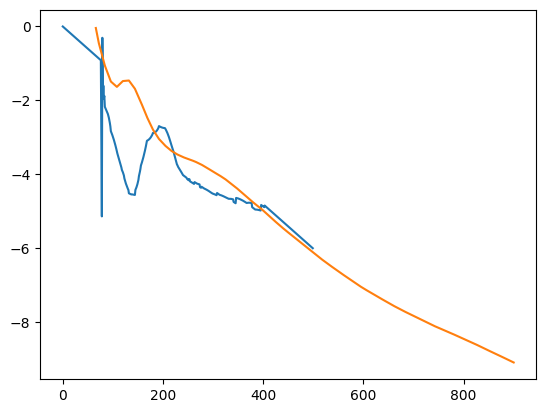

In [7]:
from scipy.optimize import fsolve, minimize, least_squares

def calculate_qb_point(h):
    return np.minimum(np.sum(pH_offshore * TG89_W(H, H_rms_offshore, h, gamma, 4))* np.diff(H).mean(), 1)

def minimize_qb_error(h, j):
    return (qb[j] - calculate_qb_point(h))**2

res = []
guess_h = np.zeros(500)
for j, h in enumerate(np.linspace(-0.001, -6, 500)):
    res.append(minimize(minimize_qb_error, h, args=j))
    guess_h[j] = res[-1].x

plt.plot(guess_h)
plt.plot(bathy.h.values[i])

   Iteration     Total nfev        Cost      Cost reduction    Step norm     Optimality   
       0              1         9.6748e+01                                    5.96e+00    
       1              2         2.9142e+01      6.76e+01       5.98e+01       7.65e-01    
       2              3         2.8550e+01      5.92e-01       2.54e+00       1.16e-01    
       3              4         2.8357e+01      1.93e-01       3.55e+00       2.03e-02    
       4              5         2.8300e+01      5.63e-02       4.66e+00       7.98e-03    
       5              6         2.8285e+01      1.58e-02       5.43e+00       5.09e-02    
       6              7         2.8280e+01      5.02e-03       5.60e-01       4.10e-02    
       7              8         2.8001e+01      2.79e-01       2.67e+00       5.07e-01    
       8              9         2.7995e+01      6.02e-03       2.53e-01       9.89e-02    
       9             10         2.7993e+01      1.71e-03       5.66e-02       8.18e-03    

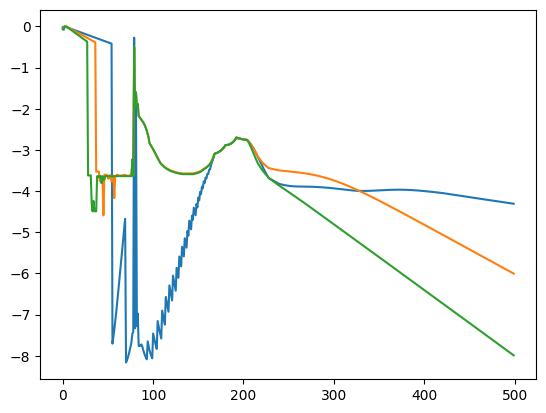

In [9]:
qb = np.nan_to_num(qb, 0)
pHGrid = rayleight_distribution(H_grid[:,:500], H_rms_offshore)
def calculate_qb_transect(h):
    return np.nan_to_num(np.minimum(np.sum(pHGrid * TG89_W(H_grid[:, :len(h)], H_rms_offshore, h, gamma=gamma), axis=0) * dH_offshore, 1), 0)

def optimize_hs_transect(h):
    return qb[:500] - calculate_qb_transect(h)

guess_h_ls_4 = least_squares(optimize_hs_transect, np.linspace(-0.001, -4, 500), verbose=2, bounds=[-10, 0], ftol=1e-6).x
guess_h_ls_6 = least_squares(optimize_hs_transect, np.linspace(-0.001, -6, 500), verbose=2, bounds=[-10, 0], ftol=1e-6).x
guess_h_ls_8 = least_squares(optimize_hs_transect, np.linspace(-0.001, -8, 500), verbose=2, bounds=[-10, 0], ftol=1e-6).x
guess_h_ls_10 = least_squares(optimize_hs_transect, np.linspace(-0.001, -10, 500), verbose=2, bounds=[-10, 0], ftol=1e-6).x

plt.plot(guess_h_ls_4)
plt.plot(guess_h_ls_6)
plt.plot(guess_h_ls_8)

Text(0.5, 1.0, 'QB Inversion offshore p(H)')

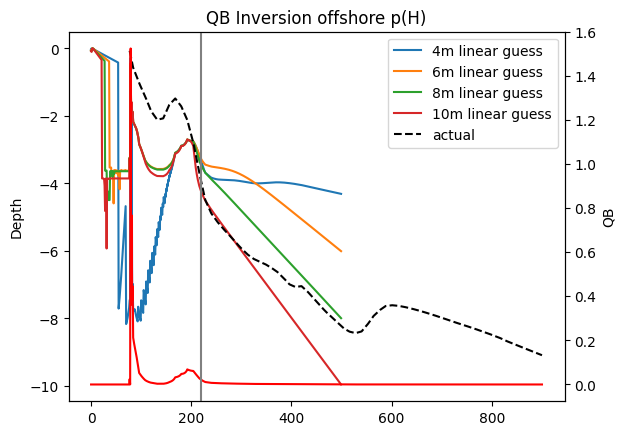

In [10]:
plt.plot(guess_h_ls_4, label='4m linear guess')
plt.plot(guess_h_ls_6, label='6m linear guess')
plt.plot(guess_h_ls_8, label='8m linear guess')
plt.plot(guess_h_ls_10, label='10m linear guess')
plt.plot(bathy.h.values[500], label='actual', linestyle='--', c='k')
plt.legend()
plt.ylabel('Depth')
plt.twinx().plot(qb, c='r')
plt.ylabel('QB')
plt.axvline(220, c='gray')
# plt.xlim(180, 300)
plt.xlabel('Crossshore')
plt.title('QB Inversion offshore p(H)')

   Iteration     Total nfev        Cost      Cost reduction    Step norm     Optimality   
       0              1         6.4494e+01                                    6.15e+00    
       1              2         5.2059e+01      1.24e+01       4.21e+00       6.10e+00    
       2              3         4.5541e+01      6.52e+00       3.15e+00       5.72e+00    
       3              4         4.2340e+01      3.20e+00       2.20e+00       4.89e+00    
       4              5         4.0450e+01      1.89e+00       1.70e+00       4.27e+00    
       5              6         3.8188e+01      2.26e+00       1.94e+00       6.09e+00    
       6              7         3.5501e+01      2.69e+00       2.30e+00       6.07e+00    
       7              8         3.4232e+01      1.27e+00       1.23e+00       4.23e+00    
       8              9         3.2381e+01      1.85e+00       2.42e+00       5.76e+00    
       9             10         3.1322e+01      1.06e+00       1.43e+00       4.10e+00    

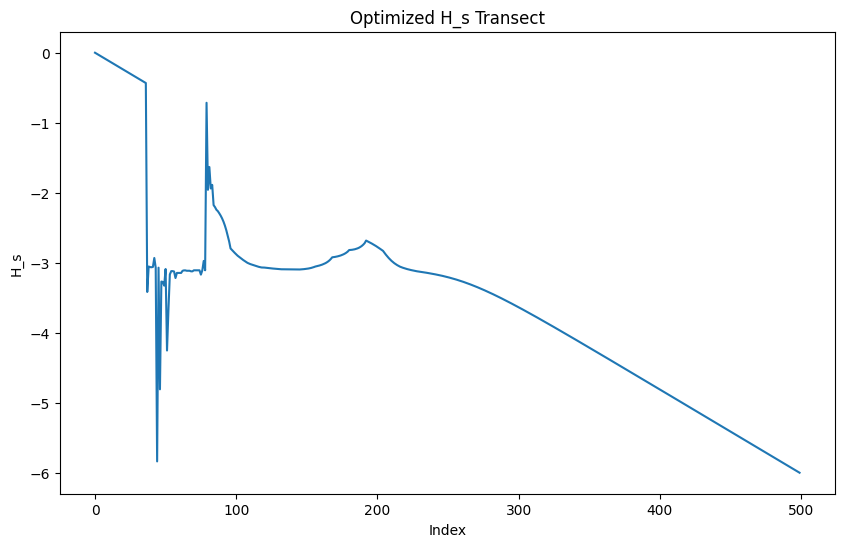

In [220]:
import numpy as np
from scipy.optimize import least_squares
import matplotlib.pyplot as plt
from numba import jit, vectorize, float32, float64, int32, int64

gamma = 0.42
n = 4

@vectorize([float32(float32, float32, float32, float32, int32),
            float64(float64, float64, float64, float64, int64),
            float64(float32, float32, float64, float32, int64)])
def TG89_W(H, H_rms, h, gamma, n):
    return min((H_rms / gamma / h) ** n * (1 - np.exp(-((H / gamma / h) ** 2))), 1)

@vectorize([float32(float32, float32),
            float64(float64, float64)])
def rayleight_distribution(H, H_rms):
    return 2 * H / H_rms**2 * np.exp(-((H / H_rms) ** 2))

@jit(nopython=True)
def calculate_qb_transect(h, H_grid, H_rms_offshore, dH_offshore, gamma, n):
    h = h.astype(np.float64)  # Ensure h is float64
    pHGrid = rayleight_distribution(H_grid[:, :len(h)], H_rms_offshore)
    return np.minimum(np.sum(pHGrid * TG89_W(H_grid[:, :len(h)], H_rms_offshore, h, gamma, n), axis=0) * dH_offshore, 1)

@jit(nopython=True)
def optimize_hs_transect(h, qb, H_grid, H_rms_offshore, dH_offshore, gamma, n):
    return qb - calculate_qb_transect(h, H_grid, H_rms_offshore, dH_offshore, gamma, n)

# Convert inputs to appropriate types
H_grid = H_grid.astype(np.float32)
H_rms_offshore = np.float32(H_rms_offshore)
dH_offshore = np.float32(dH_offshore)
qb = qb.astype(np.float64)  # Change to float64 to match optimization output

# Pre-calculate qb
qb = np.nan_to_num(qb, 0)[:500]  # Limit to 500 elements

# Use vectorized operations
initial_h = np.linspace(-0.001, -6, 500, dtype=np.float64)

# Use more efficient optimization parameters
result = least_squares(
    lambda h: optimize_hs_transect(h, qb, H_grid, H_rms_offshore, dH_offshore, gamma, n),
    initial_h,
    method='trf',
    ftol=1e-4,
    xtol=1e-4,
    gtol=1e-4,
    bounds=(-10, 0),
    verbose=2
)
guess_h_ls = result.x

plt.figure(figsize=(10, 6))
plt.plot(guess_h_ls)
plt.title('Optimized H_s Transect')
plt.xlabel('Index')
plt.ylabel('H_s')
plt.show()


/var/folders/xv/4vxt441n3tz_yllzvqvzmsgw0000gr/T/ipykernel_46992/3325741221.py:31: RuntimeWarning: divide by zero encountered in scalar divide
  h_term = 1 / (gamma * h)
/var/folders/xv/4vxt441n3tz_yllzvqvzmsgw0000gr/T/ipykernel_46992/3325741221.py:32: RuntimeWarning: invalid value encountered in multiply
  wH = np.minimum((hrms * h_term) ** 4 * (1 - np.exp(-(shoaled_H * h_term) ** 2)), 1)


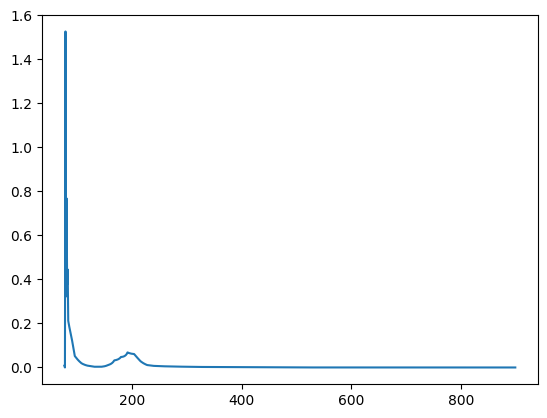

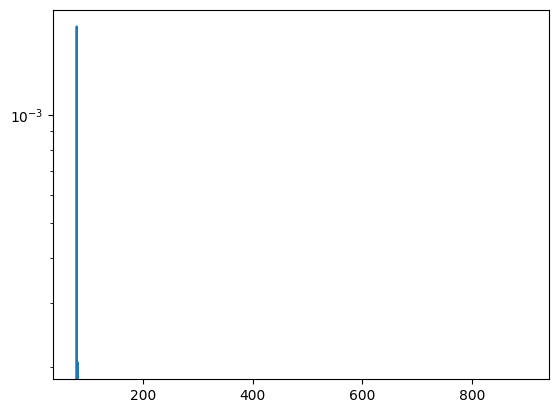

In [48]:
import numpy as np
import matplotlib.pyplot as plt

gamma = 0.42
i = 500

pH = pH_offshore
hrms = np.nan_to_num(np.sqrt(np.trapz(H**2 * pH, H)), 0)
modified_pHs = np.zeros((nx, nH))
modified_Hs = np.zeros((nx, nH))
qb = np.zeros(900)

shoaled_H = H.copy()

# Pre-compute values that don't change in the loop
h_values = bathy.h.values[i, :900]
shoaled_H_squared = shoaled_H**2
dH = np.diff(shoaled_H)
shoaled_H_midpoints = (shoaled_H[:-1] + shoaled_H[1:]) / 2

for j in range(899, -1, -1):
    h = h_values[j]
    
    pH = np.interp(shoaled_H, shoaled_H * shoaling_coefficient[j], pH)
    
    # Optimize trapz calculation for hrms
    pH_midpoints = (pH[:-1] + pH[1:]) / 2
    hrms = np.sqrt(np.sum(shoaled_H_squared[:-1] * pH_midpoints * dH))
    
    # Inline and optimize TG89_W function
    h_term = 1 / (gamma * h)
    wH = np.minimum((hrms * h_term) ** 4 * (1 - np.exp(-(shoaled_H * h_term) ** 2)), 1)
    
    pb = pH * wH
    
    pH -= pb
    # Optimize trapz calculation for pH_sum
    pH_sum = np.sum(pH[:-1] * dH)
    pH /= max(pH_sum, 1e-9)
    
    modified_pHs[j] = pH
    modified_Hs[j] = shoaled_H

    # Optimize trapz calculation for qb
    qb[j] = np.sum(pb[:-1] * dH)

# Plot the results
plt.plot(qb)
plt.show()
plt.figure()
plt.semilogy(qb-qb_original[:-1])

   Iteration     Total nfev        Cost      Cost reduction    Step norm     Optimality   
       0              1         2.0560e+00                                    8.90e+01    
       1              3         2.0187e+00      3.73e-02       2.87e-03       1.26e+02    
       2              4         1.9778e+00      4.09e-02       5.75e-03       8.78e+00    
       3              5         1.9697e+00      8.06e-03       1.17e-02       2.71e+01    
       4              6         1.9544e+00      1.53e-02       2.35e-02       5.64e+01    
       5              7         1.9304e+00      2.41e-02       4.63e-02       1.03e+02    
       6              8         1.9267e+00      3.61e-03       6.44e-02       1.30e+02    
       7              9         1.9011e+00      2.56e-02       2.33e-02       1.37e+02    
       8             10         1.8851e+00      1.60e-02       4.00e-02       4.54e+01    
       9             12         1.8794e+00      5.75e-03       2.24e-02       7.06e+01    

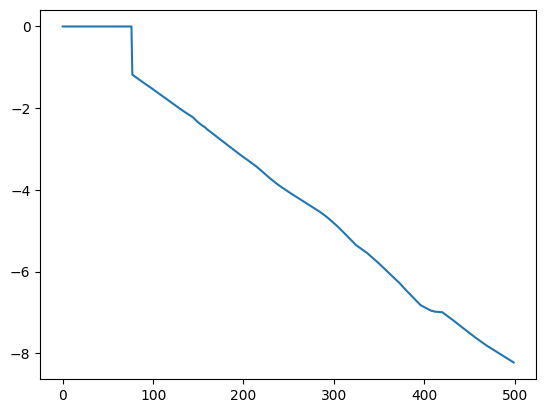

In [35]:
pH = pH_offshore
def calculate_qb_transect(h_values):
    shoaled_H_squared = shoaled_H**2
    dH = np.diff(shoaled_H)
    pH = pH_offshore
    qb = np.zeros(len(h_values))
    for j in range(len(h_values)-1, -1, -1):
        h = h_values[j]
        
        pH = np.interp(shoaled_H, shoaled_H * shoaling_coefficient[j], pH)
        
        # Optimize trapz calculation for hrms
        pH_midpoints = (pH[:-1] + pH[1:]) / 2
        hrms = np.sqrt(np.sum(shoaled_H_squared[:-1] * pH_midpoints * dH))
        
        # Inline and optimize TG89_W function
        h_term = 1 / (gamma * h)
        wH = np.minimum((hrms * h_term) ** 4 * (1 - np.exp(-(shoaled_H * h_term) ** 2)), 1)
        
        pb = pH * wH
        
        pH -= pb
        # Optimize trapz calculation for pH_sum
        pH_sum = np.sum(pH[:-1] * dH)
        pH /= max(pH_sum, 1e-9)
        
        modified_pHs[j] = pH
        modified_Hs[j] = shoaled_H

        # Optimize trapz calculation for qb
        qb[j] = np.sum(pb[:-1] * dH)

    return np.nan_to_num(qb)

def optimize_hs_transect(h):
    return qb[:500] - calculate_qb_transect(h)

initial_h = np.linspace(-0.001, -8, 500)
guess_h_ls = least_squares(optimize_hs_transect, np.nan_to_num(bathy.h.values[500, :500], 0), verbose=2, bounds=[-10, 0], ftol=1e-6).x

plt.plot(guess_h_ls)

Text(0.5, 1.0, 'QB Inversion with changing p(H)')

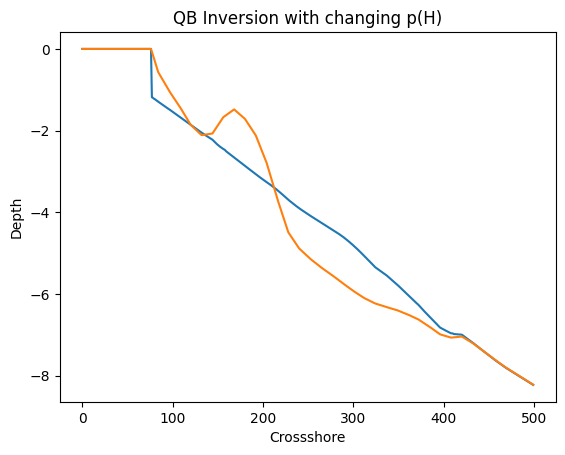

In [66]:
plt.plot(guess_h_ls)
plt.plot(bathy.h.values[500,:500])
plt.xlabel('Crossshore')
plt.ylabel('Depth')
plt.title('QB Inversion with changing p(H)')

/Users/mleclair/Dropbox/phd/code/dunex/analytical_qb/analytical_model.py:9: RuntimeWarning: divide by zero encountered in divide
  (H_rms / gamma / h) ** n * (1 - np.exp(-((H / gamma / h) ** 2))), 1
/Users/mleclair/Dropbox/phd/code/dunex/analytical_qb/analytical_model.py:9: RuntimeWarning: invalid value encountered in divide
  (H_rms / gamma / h) ** n * (1 - np.exp(-((H / gamma / h) ** 2))), 1


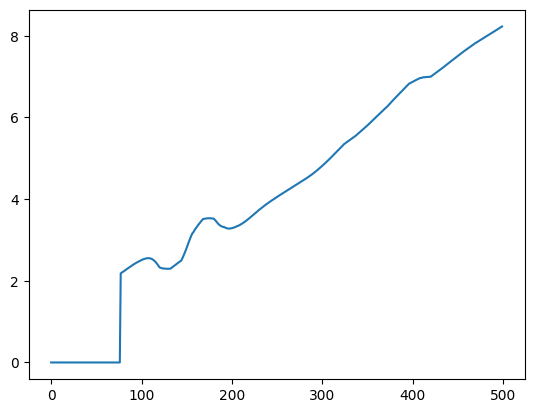

In [64]:
plt.plot(calculate_qb_transect(bathy.h.values[500,:500]) -guess_h_ls)